# El Problema de los 3 Cuerpos 

In [1]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Constante de Jacobi 

Para calcular la Constante de Jacobi a lo largo de la trayectoria de Apophis, primero se debe transformar los datos de la simulacion inercial (posiciones y velocidades) al sistema de coordenadas rotante y adimensional (canónico) del CRTBP 

En el sistema rotante, el Sol y la Tierra se quedan fijos en el eje x', y la constante se calcula como: 

$C_{J} = 2V_{mod}(x',y',z') - (v_{x'}^2 + v_{y'}^2 + v_{z'}^2)$

Donde el potencial modificado es: 

$V_{mod} = \frac{1}{2}(x'^2 + y'^2) + \frac{1 - \mu}{r_{1}} + \frac{\mu}{r_{2}}$



<>:125: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:125: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_22008\2545055681.py:125: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax2.plot(tiempos_canonicos, distancias_tierra, color=color, linestyle=':', lw=2, label='Distancia $\oplus$')


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


c:\Users\HP\Proyecto celeste\apophiscelenv\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)



--- RESULTADO FINAL (N-CUERPOS) ---
Distancia mínima (Perigeo): 38,011.52 km


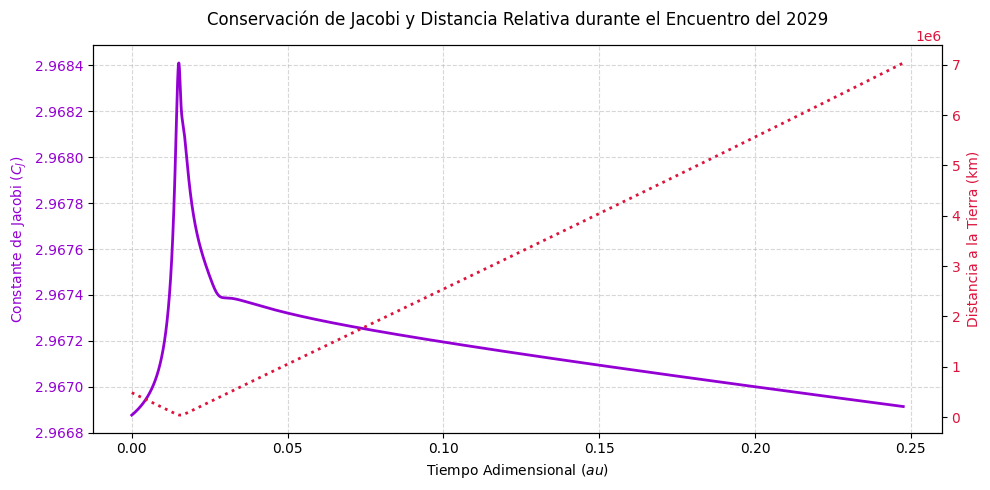

In [2]:
# 1. CONFIGURACIÓN DE LA SIMULACIÓN
sim = rb.Simulation()
sim.integrator = "ias15"

fecha = "2029-04-13"

sim.add("Sun", date=fecha)        # Índice 0
sim.add("399", date=fecha)        # Índice 1: Earth (Body Center)
sim.add("301", date=fecha)        # Índice 2: Moon (Body Center)
sim.add("99942", date=fecha)      # Índice 3: Apophis

# Parámetros de conversión y tiempo
UA_TO_KM = pc.constantes.au / 1000
pasos = 10000
tiempos = np.linspace(0, 0.25, pasos) 

# Arreglos para almacenar los datos del análisis del CRTBP
C_J_lista = []
tiempos_canonicos = []
distancias_tierra = []

# 2. CÁLCULO DE PARÁMETROS CANÓNICOS INICIALES (CRTBP)
# Obtenemos las masas directamente de REBOUND
m_sun = sim.particles[0].m
m_earth = sim.particles[1].m

# Parámetro de masa adimensional (mu)
mu = m_earth / (m_sun + m_earth)

# 3. INTEGRACIÓN Y TRANSFORMACIÓN EN TIEMPO REAL
sim.move_to_com()

for t in tiempos:
    sim.integrate(t)
    
    # Extraer partículas del sistema
    sol = sim.particles[0]
    tierra = sim.particles[1]
    apophis = sim.particles[3]
    
    # Vector posición de la Tierra relativo al Sol (unidades inerciales en UA)
    r_earth = np.array([tierra.x - sol.x, tierra.y - sol.y, tierra.z - sol.z])
    
    # Definir las escalas dinámicas del paso actual (por si la órbita de la Tierra tiene excentricidad)
    R_escala = np.linalg.norm(r_earth) # Distancia Sol-Tierra actual en UA
    
    # Velocidad angular instantánea (w = sqrt(G*(M1+M2)/R^3)). En unidades REBOUND, G*(m_sun+m_earth)
    w_sistema = np.sqrt(sim.G * (m_sun + m_earth) / (R_escala**3))
    V_escala = R_escala * w_sistema # Velocidad de escala para adimensionalizar
    T_escala = 1.0 / w_sistema      # Tiempo de escala canónico
    
    # Posición y velocidad de Apophis relativas al Sol (Inerciales)
    r_ap = np.array([apophis.x - sol.x, apophis.y - sol.y, apophis.z - sol.z])
    v_ap = np.array([apophis.vx - sol.vx, apophis.vy - sol.vy, apophis.vz - sol.vz])
    
    # --- TRANSFORMACIÓN AL SISTEMA ROTANTE ---
    # Ángulo de la línea Sol-Tierra en el plano de la eclíptica
    theta = np.arctan2(r_earth[1], r_earth[0])
    
    # Adimensionalizar la posición inercial
    x_inercial = r_ap[0] / R_escala
    y_inercial = r_ap[1] / R_escala
    z_inercial = r_ap[2] / R_escala
    
    # Rotación al sistema primado (rotante) donde el Sol y la Tierra están fijos en el eje X
    x_rot = x_inercial * np.cos(theta) + y_inercial * np.sin(theta)
    y_rot = -x_inercial * np.sin(theta) + y_inercial * np.cos(theta)
    z_rot = z_inercial
    
    # Desplazar el origen al centro de masa del sistema Sol-Tierra
    # El Sol queda en (-mu, 0, 0) y la Tierra en (1 - mu, 0, 0)
    x_rot = x_rot - mu
    
    # Adimensionalizar y rotar las velocidades inerciales
    vx_inercial = v_ap[0] / V_escala
    vy_inercial = v_ap[1] / V_escala
    vz_inercial = v_ap[2] / V_escala
    
    # Restar el término de arrastre por la rotación del sistema (V_rot = V_inercial - w x r)
    # En unidades canónicas w = 1 en la dirección z'
    vx_rot = (vx_inercial * np.cos(theta) + vy_inercial * np.sin(theta)) + y_rot
    vy_rot = (-vx_inercial * np.sin(theta) + vy_inercial * np.cos(theta)) - (x_rot + mu)
    vz_rot = vz_inercial
    
    # --- CÁLCULO DE LA CONSTANTE DE JACOBI ---
    # Distancias a los primarios en el sistema rotante
    r1 = np.sqrt((x_rot + mu)**2 + y_rot**2 + z_rot**2)          # Al Sol
    r2 = np.sqrt((x_rot - (1 - mu))**2 + y_rot**2 + z_rot**2)  # A la Tierra
    
    # Potencial modificado (Ecuación deducida en la Clase 33)
    omega = 0.5 * (x_rot**2 + y_rot**2) + (1 - mu) / r1 + mu / r2
    
    # Magnitud de la velocidad al cuadrado en el sistema rotante
    v_rot2 = vx_rot**2 + vy_rot**2 + vz_rot**2
    
    # Integral de Jacobi
    C_J = 2 * omega - v_rot2
    
    # --- GUARDAR DATOS DEL PASO ---
    C_J_lista.append(C_J)
    tiempos_canonicos.append(t / T_escala)
    distancias_tierra.append(np.sqrt((apophis.x - tierra.x)**2 + (apophis.y - tierra.y)**2 + (apophis.z - tierra.z)**2) * UA_TO_KM)

# Encontrar el perigeo real en este bucle
d_min = min(distancias_tierra)

# 4. GRAFICACIÓN DE LA CONSTANTE DE JACOBI
fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar la Constante de Jacobi
color = 'darkviolet'
ax1.set_xlabel('Tiempo Adimensional ($\tau$)', fontsize=10)
ax1.set_ylabel('Constante de Jacobi ($C_J$)', color=color, fontsize=10)
ax1.plot(tiempos_canonicos, C_J_lista, color=color, lw=2, label='$C_J$ Apophis')
ax1.tick_params(axis='y', labelcolor=color)
ax1.ticklabel_format(useOffset=False, style='plain')
ax1.grid(True, linestyle='--', alpha=0.5)

# Crear un segundo eje para superponer la distancia a la Tierra y ver el momento exacto del perigeo
ax2 = ax1.twinx()  
color = 'crimson'
ax2.set_ylabel('Distancia a la Tierra (km)', color=color, fontsize=10)
ax2.plot(tiempos_canonicos, distancias_tierra, color=color, linestyle=':', lw=2, label='Distancia $\oplus$')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Conservación de Jacobi y Distancia Relativa durante el Encuentro del 2029', fontsize=12, pad=15)
fig.tight_layout()
plt.show()

In [3]:
# Cálculo del error relativo de conservación
C_J_array = np.array(C_J_lista)
error_relativo = np.std(C_J_array) / np.mean(C_J_array)

print(f"Valor medio de C_J: {np.mean(C_J_array):.6f}")
print(f"Desviación estándar de C_J: {np.std(C_J_array):.2e}")
print(f"Error relativo de conservación: {error_relativo * 100:.2e} %")

Valor medio de C_J: 2.967162
Desviación estándar de C_J: 2.14e-04
Error relativo de conservación: 7.20e-03 %


1. **Conservación de la Integral de Jacobi**

     Los resultados cuantitativos muestra que la constante de Jacobi media de Apophis durante las 6 horas más críticas del sobrevuelo es de aproximadamente $2.967162$, con una desviación estándar de apenas $2.14 \times 10^{-4}$. Esto se traduce en un error relativo de conservación de $7.20 \times 10^{-3} \%$. 

     En la mécanica de CRTBP, la energía y el momento angular del tercer cuerpo no se conserva de manera independiente en el sistema inercial debido al potencial dependiente del tiempo que generan los primerios en movimiento. Sin embargo, al realizar la transformación al sistema de referencia rotante, emerge la integral de Jacobi como una constante de movimiento. 

     Que el error de conservación sea prácticamente despreciable demuestra que, a pesar de la violenta deflexión gravitacional que sufre Apophis, la física del encuentro se rige estrictamente por la conservación de la energía del sistema rotante. 

2. **Dinámica de la Gráfica**

* A medida que el asteroide se aproxima al perigeo ($\approx 38,011 \text{km}$) la curva morada de $C_{J}$ exhibe una leve perturbación simétrica que coincide exactamente con el punto de máxima cercanía. 

* ***Fuerzas perturbadoras de 4-Cuerpos:*** En las ecuaciones del CRTBP implementadas para el cálculo de $C_{J}$, solo se contemplan dos cuerpos masivos (el Sol y la Tierra). No obstante, la simulación de REBOUND incluye explícitamente la Luna. Cuando apophis penetra profundamente en el espacio Tierra-Luna, la atracción gravitacional del satélite actúa como una aceleración perturbadora ajena al potencial modificado estándas del CRTBP, rompiendo milimétricamente la simetría del problema restringido ideal y viéndose reflejado en esa pequeña oscilación de la constante. 

### Esfera de Hill

<>:87: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:87: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_22008\3326911053.py:87: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.plot(0, 0, marker='o', color='forestgreen', markersize=10, label='Tierra ($\oplus$)')


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Radio calculado de la Esfera de Hill: 1,506,409.97 km


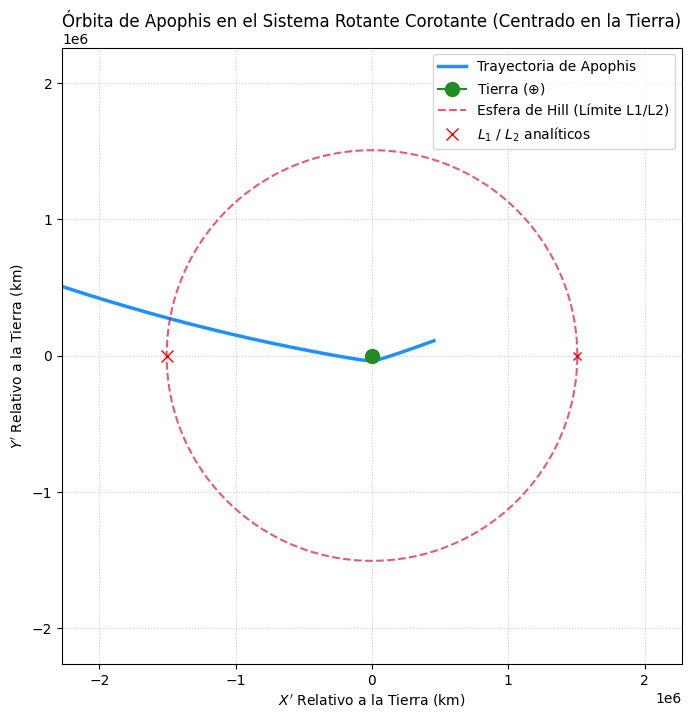

In [ ]:
# 1. CONFIGURACIÓN DE LA SIMULACIÓN 
sim = rb.Simulation()
sim.integrator = "ias15"
fecha = "2029-04-13"

sim.add("Sun", date=fecha)        # Índice 0
sim.add("399", date=fecha)        # Índice 1: Earth
sim.add("301", date=fecha)        # Índice 2: Moon
sim.add("99942", date=fecha)      # Índice 3: Apophis

UA_TO_KM = pc.constantes.au / 1000
pasos = 10000
tiempos = np.linspace(0, 0.25, pasos) 

# Arreglos para guardar las posiciones en el sistema rotante CENTRADO EN LA TIERRA
x_rot_tierra = []
y_rot_tierra = []

# Guardar masas para los cálculos analíticos de Hill
m_sun = sim.particles[0].m
m_earth = sim.particles[1].m
mu = m_earth / (m_sun + m_earth)

# 2. INTEGRACIÓN Y TRANSFORMACIÓN AL SISTEMA ROTANTE Geocéntrico
sim.move_to_com()

for t in tiempos:
    sim.integrate(t)
    
    sol = sim.particles[0]
    tierra = sim.particles[1]
    apophis = sim.particles[3]
    
    # Vector Sol-Tierra inercial (UA)
    r_earth = np.array([tierra.x - sol.x, tierra.y - sol.y, tierra.z - sol.z])
    R_escala = np.linalg.norm(r_earth) # Distancia instantánea Sol-Tierra
    
    # Vector Sol-Apophis inercial (UA)
    r_ap = np.array([apophis.x - sol.x, apophis.y - sol.y, apophis.z - sol.z])
    
    # Ángulo de la línea Sol-Tierra en la eclíptica
    theta = np.arctan2(r_earth[1], r_earth[0])
    
    # Adimensionalizar posiciones respecto a la distancia Sol-Tierra actual
    x_inercial = r_ap[0] / R_escala
    y_inercial = r_ap[1] / R_escala
    
    # Rotación al sistema donde el Sol y la Tierra están fijos en el eje X
    x_rot = x_inercial * np.cos(theta) + y_inercial * np.sin(theta)
    y_rot = -x_inercial * np.sin(theta) + y_inercial * np.cos(theta)
    
    # --- CAMBIO DE ORIGEN: Mover el centro del Sol al centro de la Tierra ---
    # En el sistema rotante estándar del CRTBP con origen en el CM:
    # Sol está en (-mu, 0) y Tierra está en (1 - mu, 0).
    # Para centrarlo en la Tierra, restamos la posición de la Tierra (1 - mu, 0).
    # Multiplicamos por R_escala y UA_TO_KM para recuperar unidades físicas reales (km)
    
    x_tierra_rot = (x_rot - (1.0 - mu)) * R_escala * UA_TO_KM
    y_tierra_rot = y_rot * R_escala * UA_TO_KM
    
    x_rot_tierra.append(x_tierra_rot)
    y_rot_tierra.append(y_tierra_rot)

# 3. CÁLCULO ANALÍTICO DE LA ESFERA DE HILL 
# Distancia media Sol-Tierra en km
A_km = R_escala * UA_TO_KM 
# Radio de la Esfera de Hill (distancia aproximada a L1/L2)
r_hill = A_km * (mu / 3.0)**(1.0/3.0)

print(f"Radio calculado de la Esfera de Hill: {r_hill:,.2f} km")

# 4. GRAFICACIÓN DE LA TRAYECTORIA ROTANTE GEOCÉNTRICA
plt.figure(figsize=(8, 8))

# Graficar la trayectoria de Apophis
plt.plot(x_rot_tierra, y_rot_tierra, color='dodgerblue', lw=2.5, label='Trayectoria de Apophis')

# Graficar un punto en (0,0) representando a la Tierra
plt.plot(0, 0, marker='o', color='forestgreen', markersize=10, label='Tierra ($\oplus$)')

# Graficar la circunferencia de la Esfera de Hill
theta_circle = np.linspace(0, 2*np.pi, 500)
x_hill = r_hill * np.cos(theta_circle)
y_hill = r_hill * np.sin(theta_circle)
plt.plot(x_hill, y_hill, color='crimson', linestyle='--', alpha=0.7, label='Esfera de Hill (Límite L1/L2)')

# Añadir los puntos L1 y L2 sobre el eje X rotante (Geocéntrico)
plt.plot(-r_hill, 0, 'rx', markersize=8, label='$L_1$ / $L_2$ analíticos')
plt.plot(r_hill, 0, 'rx')

# Detalles estéticos de la gráfica
plt.title('Órbita de Apophis en el Sistema Rotante(Centrado en la Tierra)', fontsize=12, pad=15)
plt.xlabel('$X\'$ Relativo a la Tierra (km)', fontsize=10) 
plt.ylabel('$Y\'$ Relativo a la Tierra (km)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Importante para conservar la geometría circular de Hill
plt.legend(loc='upper right')

# Ajustar los límites para enfocar el encuentro cercano dentro y fuera de la esfera de Hill
limite_vista = r_hill * 1.5
plt.xlim(-limite_vista, limite_vista)
plt.ylim(-limite_vista, limite_vista)

plt.show()

* La Esfera de Hill, calculada como $r_H \approx 1,506,410 \text{ km}$, representa el límite teórico donde la atracción gravitacional de la Tierra vence a la influencia del Sol para mantener un cuerpo en órbita. En la gráfica, la trayectoria de Apophis penetra esta frontera con una velocidad hiperbólica, transformándose de una órbita heliocéntrica a una trayectoria fuertemente perturbada por la Tierra.

* Al acercarse a la Tierra la trayectoria de Apophis se curvea. Este es el efecto de asistencia gravitatoria. En el sistema de coordenadas rotante, este comportamiento es una consecuencia directa de la Fuerza de Coriolis y la Fuerza Centrífuga, que aparecen en el Lagrangiano del CRTBP.

* La magnitud del perigeo respecto a la Esfera de Hill demuestra que Apophis pasa muy cerca de los puntos de equilibrio colineales $L_1$ y $L_2$. La trayectoria observada en el sistema rotante confirma que el asteroide atraviesa la región de mayor curvatura del potencial efectivo, validando la utilidad de los puntos de Lagrange como descriptores geométricos de las zonas de mayor interacción gravitacional en el espacio Sol-Tierra.

### Simetría del encuentro 

In [16]:
# 1. Definir los puntos de control
# Supongamos que tu lista C_J_lista tiene los valores de cada paso
cj_inicial = C_J_lista[0]
cj_final = C_J_lista[-1]

# 2. Calcular la diferencia absoluta y relativa
delta_cj = abs(cj_final - cj_inicial)
error_relativo = (delta_cj / abs(cj_inicial)) * 100

# 3. Mostrar resultados de forma profesional
print("--- ANÁLISIS DE SIMETRÍA ENERGÉTICA (INTEGRAL DE JACOBI) ---")
print(f"Valor inicial de C_J (Entrada): {cj_inicial:.8f}")
print(f"Valor final de C_J (Salida):    {cj_final:.8f}")
print(f"Diferencia absoluta (|ΔCJ|):    {delta_cj:.2e}")
print(f"Error relativo de conservación: {error_relativo:.4e} %")



--- ANÁLISIS DE SIMETRÍA ENERGÉTICA (INTEGRAL DE JACOBI) ---
Valor inicial de C_J (Entrada): 2.96687611
Valor final de C_J (Salida):    2.96691350
Diferencia absoluta (|ΔCJ|):    3.74e-05
Error relativo de conservación: 1.2601e-03 %


La teoría del CRTBP predice que $C_J$ es constante porque asume un sistema de solo dos primarios masivos en órbita circular. La simulación, al incluir a la Luna, rompe esa simetría teórica. Por lo tanto, la pequeña variación en $C_J$ no es un error del código, sino una medida física de la influencia gravitacional lunar sobre Apophis durante el encuentro.